# Explore The Data

## 1. Explore The Data Lable

In [1]:
import pickle
DATA_PATH_PREFIX='/mnt/d/DataSets/WESAD'
SUBJECT_ID = 'S2'
try:
    with open(f"{DATA_PATH_PREFIX}/{SUBJECT_ID}/{SUBJECT_ID}.pkl", 'rb') as f:
        data = pickle.load(f, encoding="latin1")
        print(f"Data Load Successfully!")
except FileNotFoundError as e:
    print(f"Error:{e}")


Data Load Successfully!


In [2]:
print("\n--- Data Structure Overview ---")
print(f"Keys in loaded data: {data.keys()}")


--- Data Structure Overview ---
Keys in loaded data: dict_keys(['signal', 'label', 'subject'])


In [3]:
signal_data = data['signal']
print(f"Keys in signal: {signal_data.keys()}")

Keys in signal: dict_keys(['chest', 'wrist'])


In [4]:
chest_data = signal_data['chest']
print(f"Keys in chest: {chest_data.keys()}")

Keys in chest: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [5]:
# Extract data from the chest_data and labels
ecg_data = chest_data['ECG']
labels = data['label']

print(f"ECG signal shape: {ecg_data.shape}")
print(f"Labels shape: {labels.shape}")

emg_data = chest_data['EMG']
print(f"EMG signal shape: {emg_data.shape}")

eda_data = chest_data['EDA']
print(f"EDA signal shape: {eda_data.shape}")

temp_data = chest_data['Temp']
print(f"Temperature signal shape: {temp_data.shape}")

resp_data = chest_data['Resp']
print(f"Respiration signal shape: {resp_data.shape}")

acc_data = chest_data['ACC']
print(f"Accelerometer signal shape: {acc_data.shape}")

ECG signal shape: (4255300, 1)
Labels shape: (4255300,)
EMG signal shape: (4255300, 1)
EDA signal shape: (4255300, 1)
Temperature signal shape: (4255300, 1)
Respiration signal shape: (4255300, 1)
Accelerometer signal shape: (4255300, 3)


In [6]:
wrist_data=signal_data['wrist']
print(f"Keys in wrist: {wrist_data.keys()}")

Keys in wrist: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [7]:
bvp_data=wrist_data['BVP']
print(f"BVP signal shape: {bvp_data.shape}")
wrist_eda_data=wrist_data['EDA']
print(f"EDA signal shape: {wrist_eda_data.shape}")
wrist_temp_data=wrist_data['TEMP']
print(f"Temperature signal shape: {wrist_temp_data.shape}")
wrist_acc_data=wrist_data['ACC']
print(f"Acceleration signal shape: {wrist_acc_data.shape}")

BVP signal shape: (389056, 1)
EDA signal shape: (24316, 1)
Temperature signal shape: (24316, 1)
Acceleration signal shape: (194528, 3)


### Inspect the subject's label of the dataset

In [46]:
RESP_SAMPLING_RATE = 700 # Hz (from WESAD documentation for RespiBAN ECG)
LABEL_SAMPLING_RATE = 700 # Hz (from WESAD documentation for labels)
HRV_INTERPOLATION_RATE = 4 # Hz (Common for HRV spectral analysis, as per RHRV example in the wavelet paper)
BVP_SAMPLING_RATE = 64 # Hz (from WESAD documentation for BVP)
E4_SAMPLING_RATE = 4 # Hz
PLOT_TIME = 30 # seconds (for plotting)

In [9]:
import numpy as np
unique_labels = np.unique(labels)
print(f"Unique labels: {unique_labels}")

# Count the number of samples for each label
lbl_cnt_dict={}
lbl_name_dict={1: "Baseline", 2: "Stress", 3: "Amusement", 0: "Transient"}
for label in unique_labels:
    lbl_name = lbl_name_dict.get(label, "Unknown")
    lbl_cnt = len(labels[labels==label])
    period= lbl_cnt/RESP_SAMPLING_RATE
    print(f"Label {label}({lbl_name:10}): {lbl_cnt:7,} samples, Duration: {period:.3f} seconds")
    lbl_cnt_dict[label] = (lbl_cnt,period)

Unique labels: [0 1 2 3 4 6 7]
Label 0(Transient ): 2,142,701 samples, Duration: 3061.001 seconds
Label 1(Baseline  ): 800,800 samples, Duration: 1144.000 seconds
Label 2(Stress    ): 430,500 samples, Duration: 615.000 seconds
Label 3(Amusement ): 253,400 samples, Duration: 362.000 seconds
Label 4(Unknown   ): 537,599 samples, Duration: 767.999 seconds
Label 6(Unknown   ):  45,500 samples, Duration: 65.000 seconds
Label 7(Unknown   ):  44,800 samples, Duration: 64.000 seconds


## 2.Visualise the Raw Data

### 2.1 Visulise the raw data from the RespiBAN chest sensor

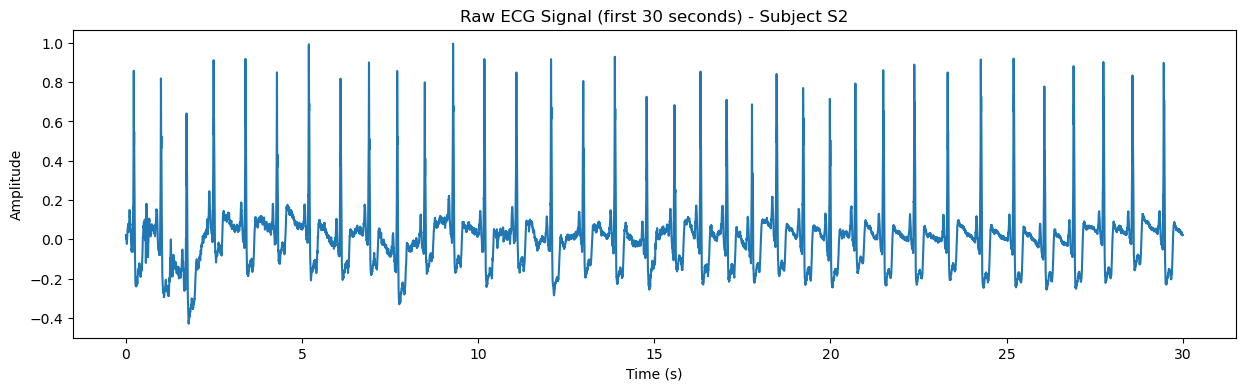

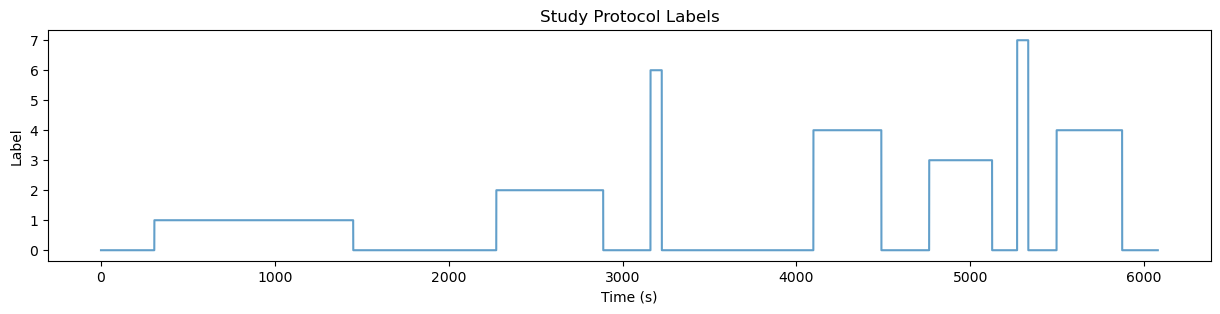

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(np.arange(RESP_SAMPLING_RATE*PLOT_TIME) / RESP_SAMPLING_RATE, 
         ecg_data[:RESP_SAMPLING_RATE*PLOT_TIME])
plt.title(f'Raw ECG Signal (first {PLOT_TIME} seconds) - Subject {SUBJECT_ID}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(15, 3))
plt.plot(np.arange(len(labels)) / LABEL_SAMPLING_RATE, labels, alpha=0.7)
plt.title('Study Protocol Labels')
plt.xlabel('Time (s)')
plt.ylabel('Label')
plt.show()

In [11]:
def raw_data_plot(data:list, data_tpye:str):
    plt.figure(figsize=(15, 4))
    plt.plot(np.arange(RESP_SAMPLING_RATE*PLOT_TIME) / RESP_SAMPLING_RATE, 
         data[:RESP_SAMPLING_RATE*PLOT_TIME])
    plt.title(f'Raw {data_tpye} Signal (first {PLOT_TIME} seconds) - Subject {SUBJECT_ID}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()

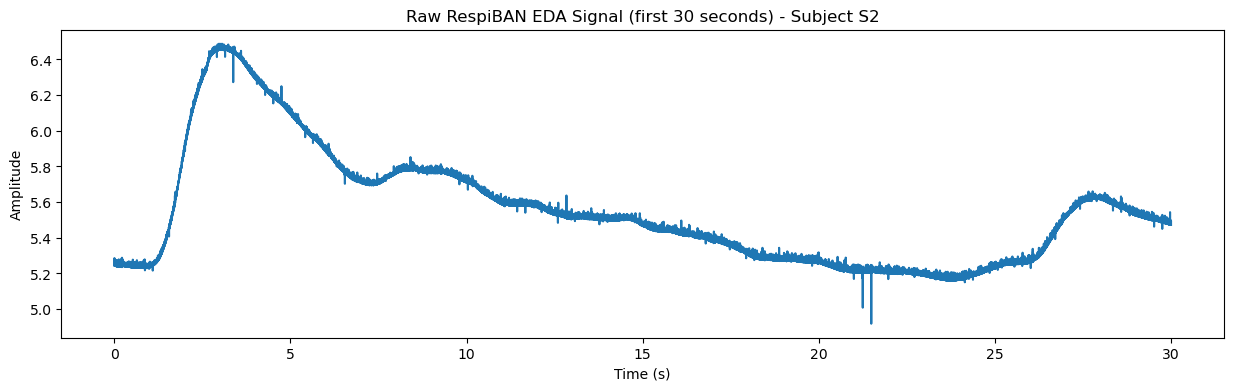

In [12]:
raw_data_plot(eda_data,'RespiBAN EDA')

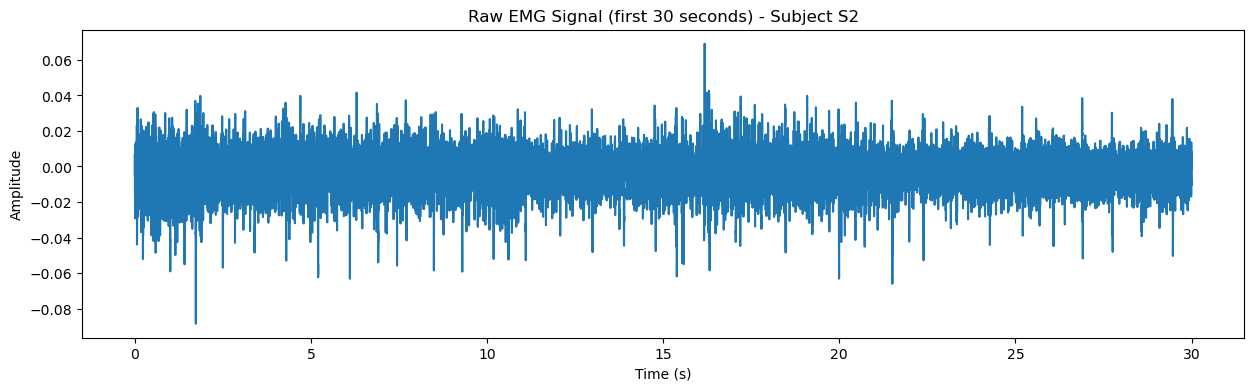

In [13]:
raw_data_plot(emg_data,'EMG')

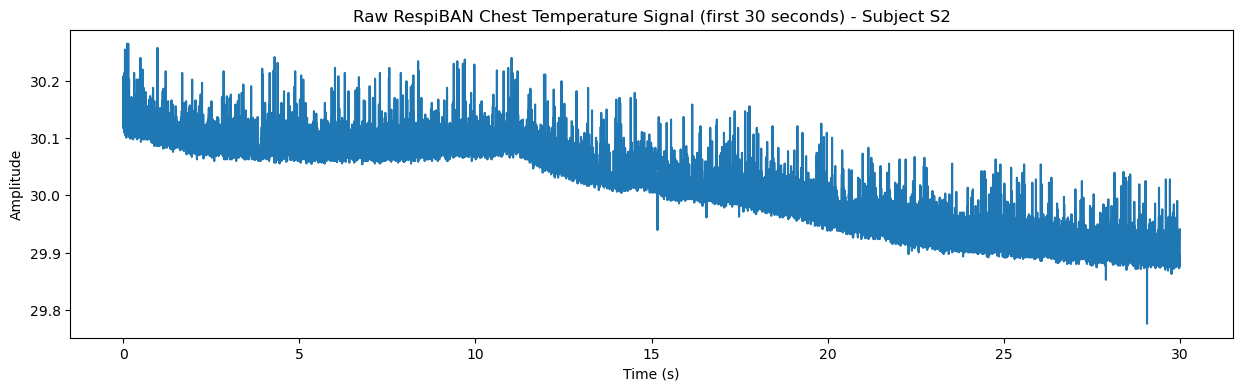

In [14]:
raw_data_plot(temp_data, 'RespiBAN Chest Temperature')

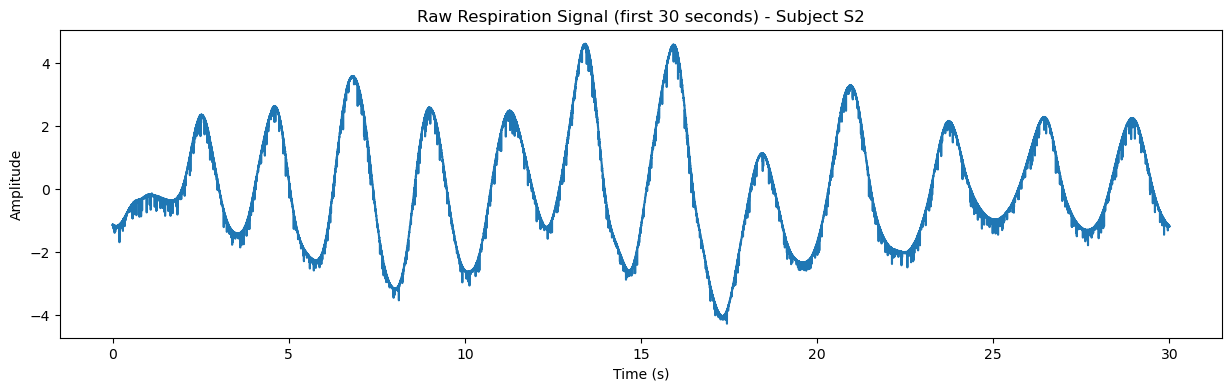

In [15]:
raw_data_plot(resp_data, 'Respiration')

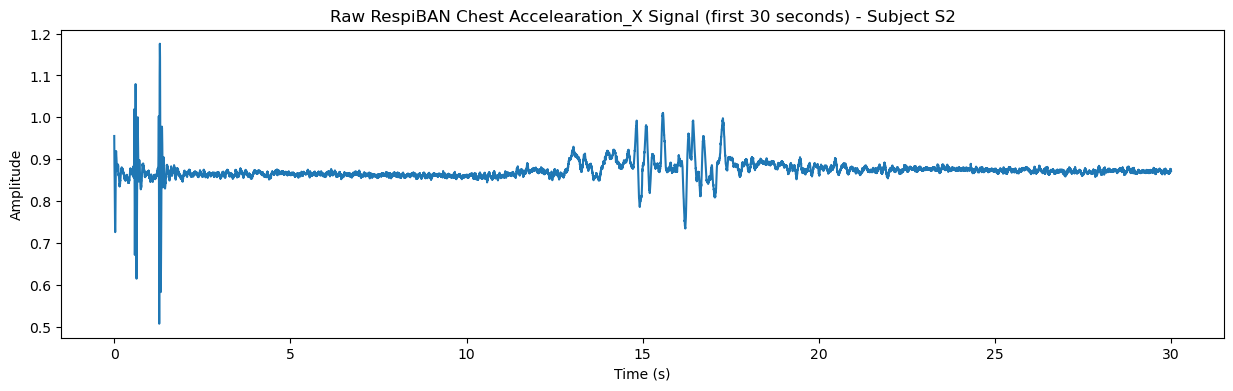

In [16]:
acc_x_data=[row[0] for row in acc_data]
raw_data_plot(acc_x_data,'RespiBAN Chest Accelearation_X')

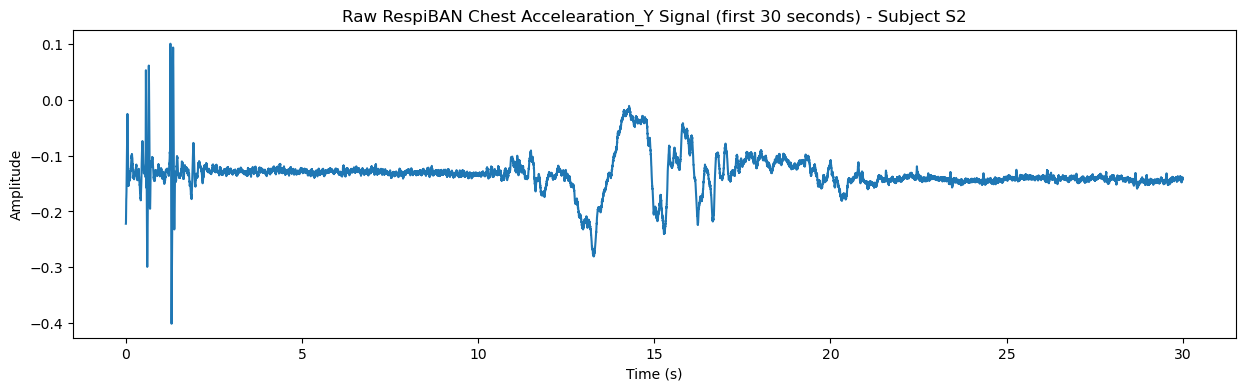

In [17]:
acc_y_data=[row[1] for row in acc_data]
raw_data_plot(acc_y_data,'RespiBAN Chest Accelearation_Y')

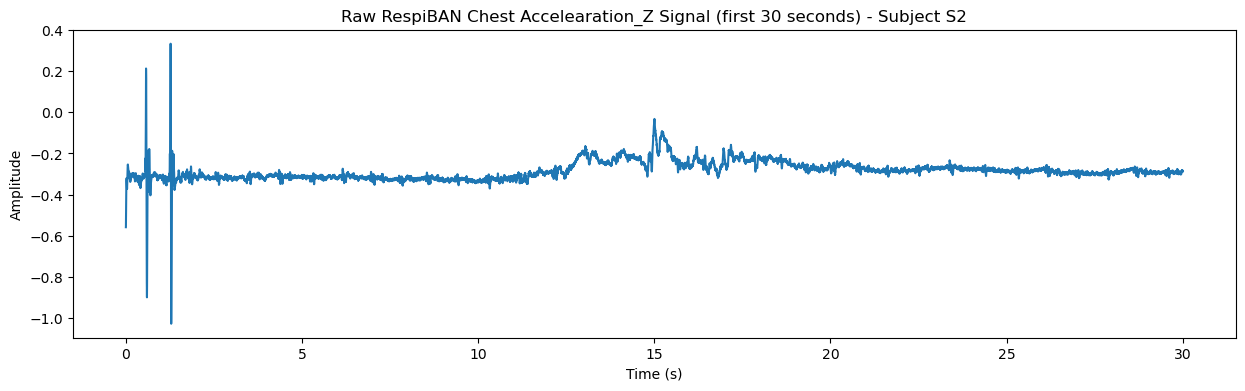

In [18]:
acc_z_data=[row[2] for row in acc_data]
raw_data_plot(acc_z_data,'RespiBAN Chest Accelearation_Z')

### 2.1.2 Visualse the raw data from Empatica E4 wrist senor

In [59]:
def raw_data_plot2(data:list, data_tpye:str, sensor_type:str):
    plt.figure(figsize=(15, 4))
    if sensor_type == 'RESP':
        sampling_rate =RESP_SAMPLING_RATE
    elif sensor_type == 'E4':
        sampling_rate = BVP_SAMPLING_RATE
    else:
        sampling_rate =RESP_SAMPLING_RATE
    plt.plot(np.arange(sampling_rate*PLOT_TIME) / sampling_rate, 
         data[:sampling_rate*PLOT_TIME])
    plt.title(f'Raw {data_tpye} Signal (first {PLOT_TIME} seconds) - Subject {SUBJECT_ID}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()

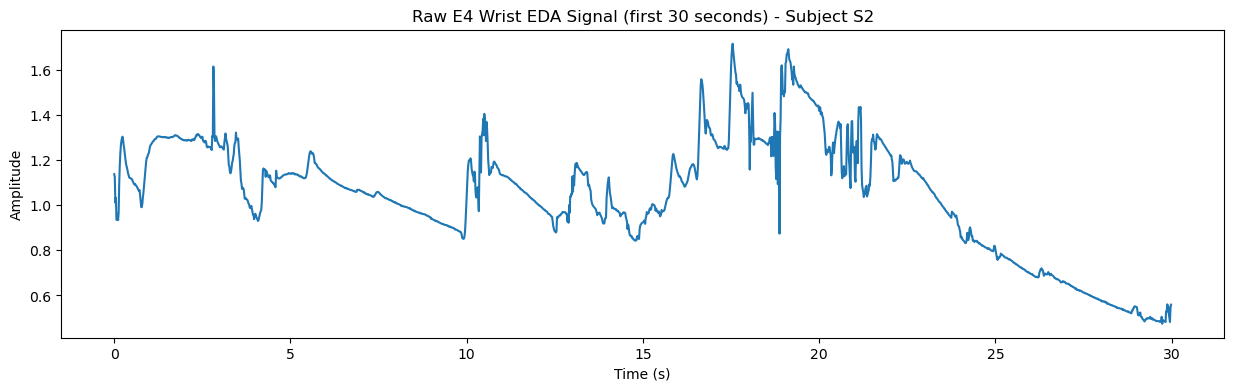

In [60]:
raw_data_plot2(wrist_eda_data,'E4 Wrist EDA','E4')

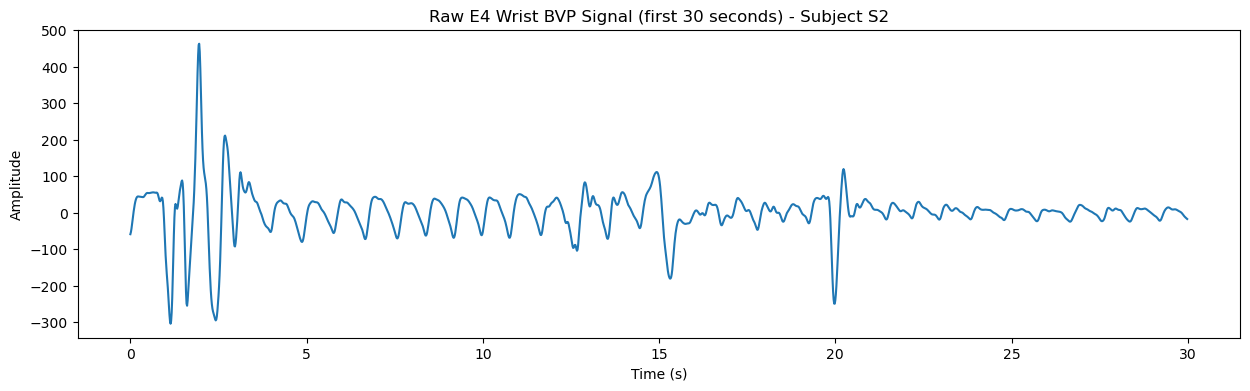

In [62]:
raw_data_plot2(bvp_data,'E4 Wrist BVP','E4')

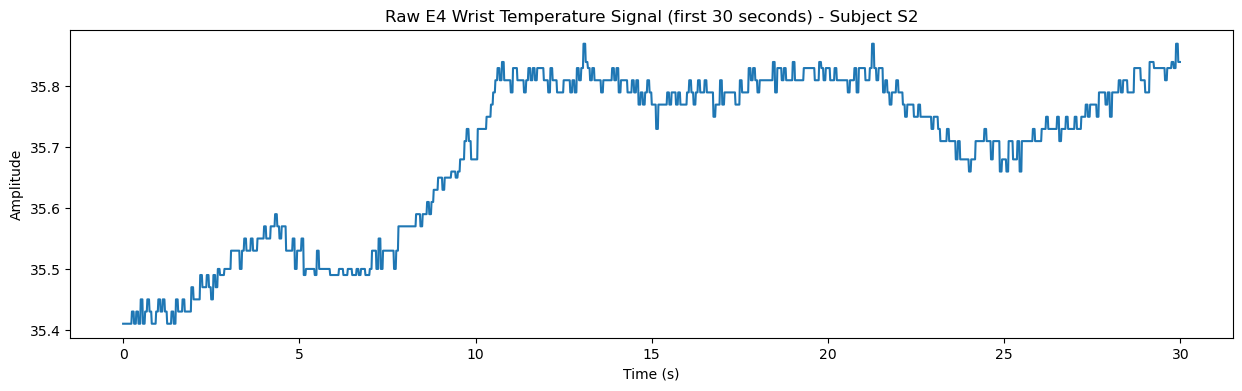

In [63]:
raw_data_plot2(wrist_temp_data,'E4 Wrist Temperature','E4')

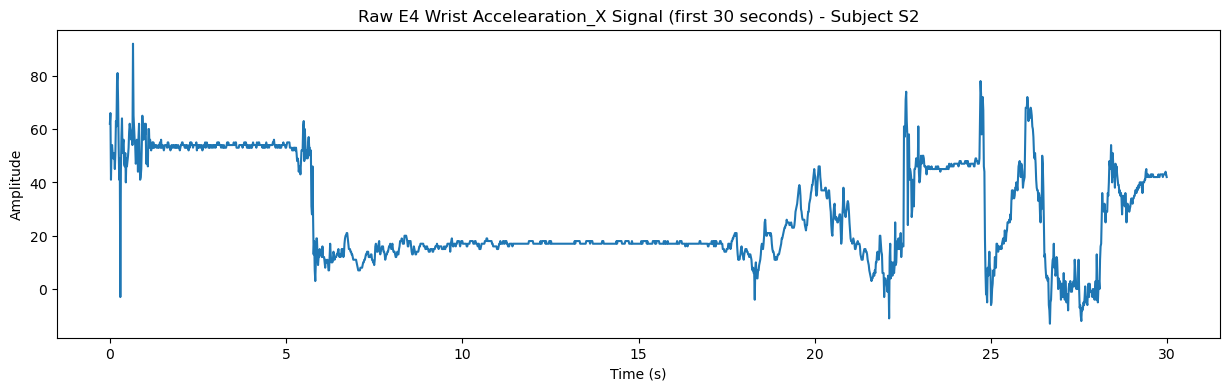

In [64]:
wist_acc_x_data=[row[0] for row in wrist_acc_data]
raw_data_plot2(wist_acc_x_data,'E4 Wrist Accelearation_X','E4')

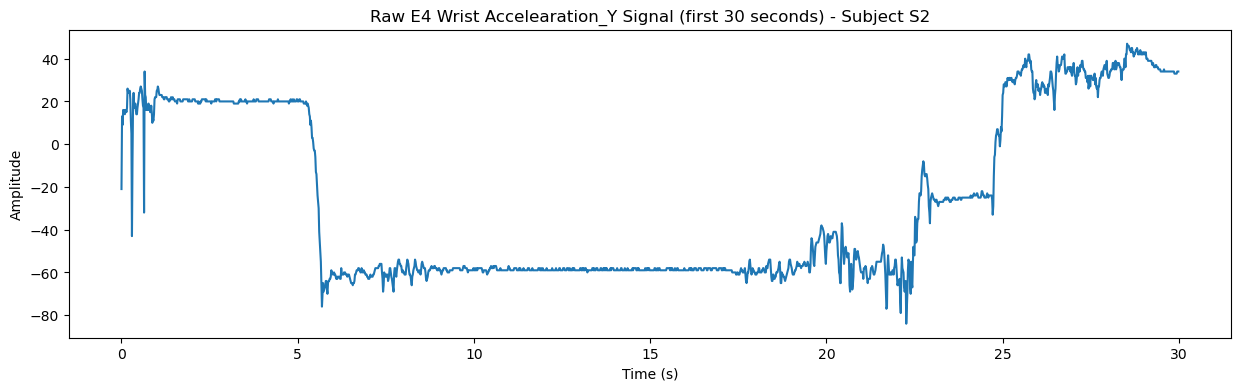

In [65]:
wist_acc_y_data=[row[1] for row in wrist_acc_data]
raw_data_plot2(wist_acc_y_data,'E4 Wrist Accelearation_Y','E4')

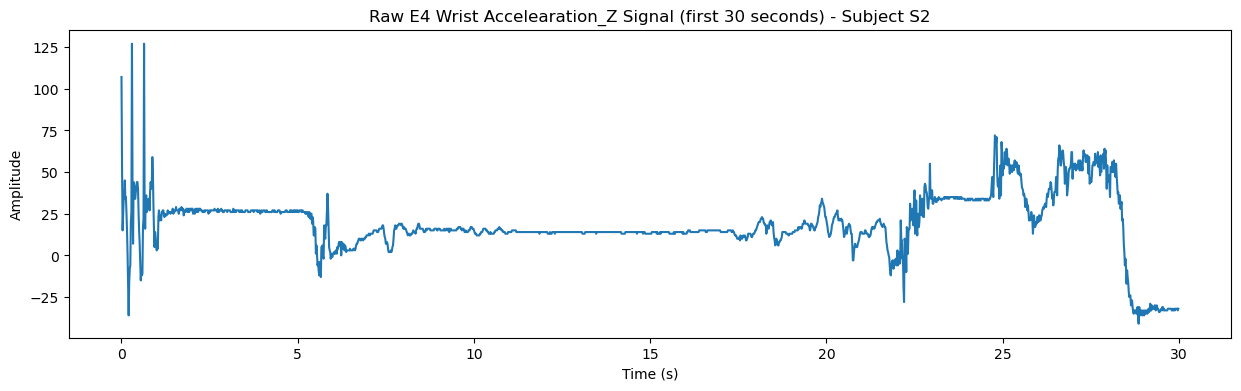

In [66]:
wist_acc_z_data=[row[2] for row in wrist_acc_data]
raw_data_plot2(wist_acc_z_data,'E4 Wrist Accelearation_Z','E4')

## 3. Data Preprocess for Empatica E4 wrist senors data

### 3.1 Filtering and Feature Extraction

In [28]:
print("---  RR Interval Extraction from BVP Data ---")
print(f"Processing BVP signal of length {len(bvp_data)} samples at {BVP_SAMPLING_RATE} Hz...")

---  RR Interval Extraction from BVP Data ---
Processing BVP signal of length 389056 samples at 64 Hz...


In [29]:
import neurokit2 as nk
bvp_data_filtered,bvp_info=nk.ppg_process(bvp_data, sampling_rate=BVP_SAMPLING_RATE)

In [35]:
print("BVP Info Keys: ",bvp_info.keys())
print("BVP PPG Peaks' shape:", bvp_info["PPG_Peaks"].shape)
print("BVP PPG Peaks' Indecies:", bvp_info["PPG_Peaks"])
print(f"Detected {len(bvp_info['PPG_Peaks'])} R peaks in BVP data.")

BVP Info Keys:  dict_keys(['method_peaks', 'method_fixpeaks', 'PPG_Peaks', 'sampling_rate'])
BVP PPG Peaks' shape: (6899,)
BVP PPG Peaks' Indecies: [    48     93    125 ... 388857 388920 388977]
Detected 6899 R peaks in BVP data.


In [44]:
import pandas as pd
bvp_peaks_num=len(bvp_info['PPG_Peaks'])
bvp_T = 1/BVP_SAMPLING_RATE*1000
if bvp_peaks_num>1:
    bvp_rr_intervals=np.diff(bvp_info['PPG_Peaks'])*bvp_T
    bvp_rr_events=bvp_info['PPG_Peaks'][1:]*bvp_T
    bvp_rr_df = pd.DataFrame({'RR_Intervals(ms)': bvp_rr_intervals, 'RR_Event(ms)': bvp_rr_events})
    print(f"Extracted {len(bvp_rr_events)} RR intervals.")
    print(bvp_rr_df[:5])

Extracted 6898 RR intervals.
   RR_Intervals(ms)  RR_Event(ms)
0           703.125      1453.125
1           500.000      1953.125
2           734.375      2687.500
3           437.500      3125.000
4          1140.625      4265.625


In [47]:
print(f"Processing E4 Wrist EDA signal of length {len(wrist_eda_data)} samples at {E4_SAMPLING_RATE} Hz...")

Processing E4 Wrist EDA signal of length 24316 samples at 4 Hz...


In [67]:
wrist_eda_processed, wrist_eda_info = nk.eda_process(wrist_eda_data.ravel(),E4_SAMPLING_RATE)
print(wrist_eda_processed.head())
print("wrist_eda_processed data rows: ",wrist_eda_processed.shape[0])
print(wrist_eda_processed[:5])
print(wrist_eda_info.keys())

/home/jackey/miniconda3/envs/PhysioSenseTS/lib/python3.10/site-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


    EDA_Raw  EDA_Clean  EDA_Tonic  EDA_Phasic  SCR_Onsets  SCR_Peaks  \
0  1.138257   1.138257   1.170136   -0.031879           0          0   
1  1.125444   1.125444   1.168460   -0.043016           0          0   
2  1.011405   1.011405   1.166819   -0.155414           0          0   
3  1.033188   1.033188   1.165236   -0.132048           0          0   
4  0.935807   0.935807   1.163730   -0.227923           0          0   

   SCR_Height  SCR_Amplitude  SCR_RiseTime  SCR_Recovery  SCR_RecoveryTime  
0         0.0            0.0           0.0             0               0.0  
1         0.0            0.0           0.0             0               0.0  
2         0.0            0.0           0.0             0               0.0  
3         0.0            0.0           0.0             0               0.0  
4         0.0            0.0           0.0             0               0.0  
wrist_eda_processed data rows:  24316
    EDA_Raw  EDA_Clean  EDA_Tonic  EDA_Phasic  SCR_Onsets  SCR_Peak

## Extract the RR Interval data from the ECG signal

In [ ]:
import pandas as pd
import neurokit2 as nk
print("\n--- II. RR Interval Extraction from ECG ---")
print(f"Processing ECG signal of length {len(ecg_data)} samples at {RESP_SAMPLING_RATE} Hz...")

# Initialize variables to store results and defaults
rr_df = pd.DataFrame()
rpeaks_indices = np.array([])

try:
    # Clean ECG signal
    print("Cleaning ECG signal...")
    cleaned_ecg = nk.ecg_clean(ecg_data, sampling_rate=RESP_SAMPLING_RATE)

    # Detect R-peaks
    print("Detecting R-peaks...")
    _, rpeaks = nk.ecg_peaks(cleaned_ecg, sampling_rate=RESP_SAMPLING_RATE)

    # Extract R-peak indices
    rpeaks_indices = rpeaks['ECG_R_Peaks']
    print(f"R-peak indices: {rpeaks_indices[:5]}")
    print(f"Detected {len(rpeaks_indices)} R-peaks.")

    if len(rpeaks_indices) > 1:
        # Compute RR intervals in ms
        rr_intervals_ms_seq = np.diff(rpeaks_indices) / RESP_SAMPLING_RATE * 1000
        rr_event_sec_seq = rpeaks_indices[1:] / RESP_SAMPLING_RATE
        rr_df = pd.DataFrame({'RR_Intervals_ms': rr_intervals_ms_seq, 'RR_Event_sec': rr_event_sec_seq})
        print(f"Extracted {len(rr_intervals_ms_seq)} RR intervals.")
        print(rr_df[:5])
    else:
        print("No RR intervals detected.")

except Exception as e:  
    print(f"Error: {e}")




--- II. RR Interval Extraction from ECG ---
Processing ECG signal of length 4255300 samples at 700 Hz...
Cleaning ECG signal...
Detecting R-peaks...
R-peak indices: [ 699 1208 1745 2378 3002]
Detected 7250 R-peaks.
Extracted 7249 RR intervals.
   RR_Intervals_ms  RR_Times_sec
0       727.142857      1.725714
1       767.142857      2.492857
2       904.285714      3.397143
3       891.428571      4.288571
4       907.142857      5.195714


## 3. Data Preprocessing

### 3.1 Unify the time axis of all signals: downsample the signals to the same frequence to 4Hz

#### 3.1.1 Downsample the data from Empatica E4 wrist sensor

In [ ]:
import scipy.signal as sg

period = len(labels)* 1/RESP_SAMPLING_RATE
target_data_len = int(period * HRV_INTERPOLATION_RATE)

bvp_resampled = sg.resample(bvp_data, target_data_len)
bvp_resampled = bvp_resampled.reshape(-1,1)
print(f"Resampled BVP data shape: {bvp_resampled.shape}")
acc_resampled = sg.resample(acc_data, target_data_len, axis=0) if acc_data.ndim == 2 else sg.resample(acc_data, target_data_len)

# EDA and TEMP data do not need to be resampled as they are already at the desired sampling rate: 4 Hz
# eda_resampled = sg.resample(eda_data, target_data_len)
# print(f"Resampled EDA data shape: {eda_resampled.shape}")
# temp_resampled = sg.resample(temp_data, target_data_len)

labels_resampled = sg.resample(labels, target_data_len)
labels_resampled = np.round(labels_resampled).reshape(-1, 1)


Resampled BVP data shape: (24316, 1)
Resampled EDA data shape: (24316, 1)


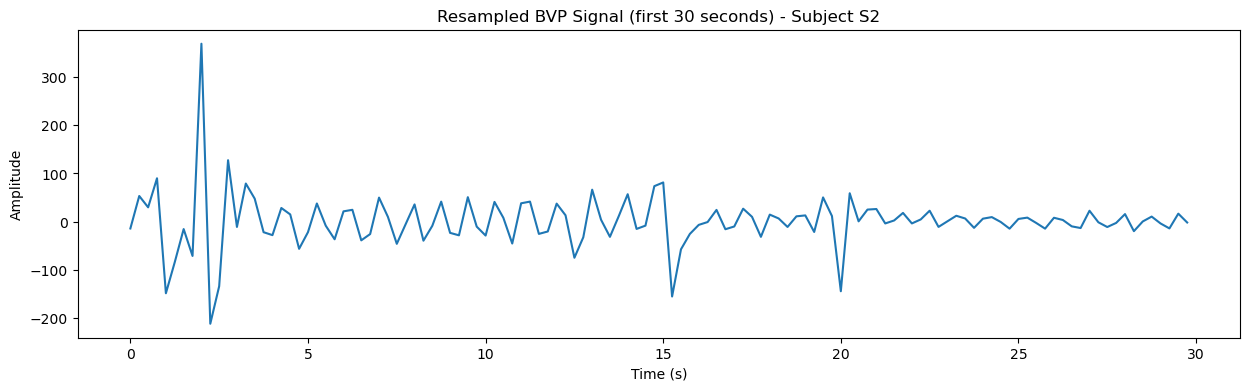

In [36]:
plt.figure(figsize=(15, 4))
plt.plot(np.arange(HRV_INTERPOLATION_RATE*PLOT_TIME)/HRV_INTERPOLATION_RATE, bvp_resampled[:HRV_INTERPOLATION_RATE*PLOT_TIME])
plt.title(f'Resampled BVP Signal (first {PLOT_TIME} seconds) - Subject {SUBJECT_ID}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

In [ ]:
# Combine the resampled data from Empatica E4 wrist senors.
wrist_comb_data=np.hstack([acc_resampled,bvp_resampled,eda_data,temp_data])
print(f"Shape of wrist_comb_data: {wrist_comb_data.shape}")
print(f"Wrist Combined Data: {wrist_comb_data[:HRV_INTERPOLATION_RATE][:]}")

Shape of wrist_comb_data: (24316, 6)
Wrist Combined Data: [[ 52.94911954  13.61734649  39.45444163 -14.16497821   1.138257
   35.41      ]
 [ 55.55089067  18.25923549  20.12928983  53.20926038   1.125444
   35.41      ]
 [ 55.18216443  13.5613409    5.89430368  29.694548     1.011405
   35.41      ]
 [ 46.29642644   9.03899793  53.97909678  89.98838715   1.033188
   35.41      ]]
